# Data Center Cooling Demand, Electricity and Water Requirement Analysis

## Problem Statement

Data centers consume significant amounts of electricity, which is ultimately converted into heat and must be removed through cooling systems. Efficiently estimating cooling requirements and the associated water demand is important for reducing energy and water consumption.

This project analyzes data center workload, power consumption, temperature, and cooling-related parameters to understand their relationship with heat generation and estimate the water required for cooling.

## Objective

To develop a predictive analytics system that analyzes data center operational conditions and predicts cooling and water requirements while studying the relationship between workload, electricity consumption, heat generation, and cooling demand.

## Proposed Approach

The project follows an end-to-end predictive analytics approach:

- Exploratory Data Analysis of data center operational data
- Feature engineering and extraction
- Thermal and energy-related measure creation
- Physics-based estimation of cooling and water requirements
- Feature selection
- Predictive modeling
- Model evaluation and comparison
- Cooling and water-demand analysis
- Decision-support insights

#### Step 1: Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Data Loading

In [5]:
df = pd.read_csv('..\datasets\Tu-wien.csv')
df.head()

,Series,Time,CPU_Load,Power,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Fan_speed1,Fan_speed2,Fan_speed3,Fan_speed4,Ram,Ram_Used,No_Of_Running_vms,CPU_cores,CPU_cores_used
0,qh2-rcc120,2018-10-09 11:20:00,3.468500,90.533333,408343.338389,147737.953254,16.966667,37.083333,36.716667,7502.833333,7571.666667,7500.500000,7462.000000,64.454875,37.70275,15.0,64.0,63.0
1,qh2-rcc120,2018-10-09 11:30:00,3.622833,88.933333,44589.407008,202395.924763,17.000000,37.783333,37.083333,7141.166667,7182.000000,7147.000000,7113.166667,64.454875,37.70275,15.0,64.0,63.0
2,qh2-rcc120,2018-10-09 11:40:00,3.414500,88.800000,40146.872453,157905.963285,17.000000,38.233333,37.466667,6728.166667,6802.833333,6743.333333,6729.333333,64.454875,37.70275,15.0,64.0,63.0
3,qh2-rcc120,2018-10-09 11:50:00,3.332500,89.866667,441692.385339,142941.034500,17.000000,38.183333,37.550000,6813.333333,6856.500000,6808.666667,6771.333333,64.454875,37.70275,15.0,64.0,63.0
4,qh2-rcc120,2018-10-09 12:00:00,3.364000,89.600000,422057.822324,770341.893781,16.950000,37.416667,36.866667,7390.833333,7445.666667,7401.333333,7351.166667,64.454875,37.70275,15.0,64.0,63.0


#### Step 3: Data Profiling

In [6]:
def data_profile(data):
    print(15 * '*', "DATA SHAPE", 15 * '*')
    print("Shape:", data.shape)

    print(15 * '*', "DATA COLUMNS & DTYPES", 15 * '*')
    print("Columns:")
    print(data.columns.tolist())
    print("\nData Types:")
    print(data.dtypes)

    print(15 * '*', "DATA INFO", 15 * '*')
    data.info()

    print(15 * '*', "DATA DESCRIPTION", 15 * '*')
    print(data.describe(include="all"))

    print(15 * '*', "MISSING VALUES", 15 * '*')
    print("Missing Count:")
    print(data.isna().sum())

    print("\nMissing Percentage:")
    print(data.isna().mean().mul(100).round(2))

    print(15 * '*', "DUPLICATES IDENTIFICATION", 15 * '*')
    print("Duplicate Rows:", data.duplicated().sum())

    print(15 * '*', "UNIQUE VALUES / CARDINALITY", 15 * '*')
    print(data.nunique(dropna=False))

    print(15 * '*', "CATEGORICAL VALUE COUNTS", 15 * '*')
    categorical_cols = data.select_dtypes(include=["object", "category", "bool"]).columns
    for col in categorical_cols:
        print(f"\n{col}:")
        print(data[col].value_counts(dropna=False))

    print(15 * '*', "DATA CORRELATION", 15 * '*')
    print(data.corr(numeric_only=True))

In [7]:
data_profile(df)

*************** DATA SHAPE ***************
Shape: (2748525, 18)
*************** DATA COLUMNS & DTYPES ***************
Columns:
['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used']

Data Types:
Series                object
Time                  object
CPU_Load             float64
Power                float64
Network_RX           float64
Network_TX           float64
Inlet_Temperature    float64
CPU1_Temperature     float64
CPU2_Temperature     float64
Fan_speed1           float64
Fan_speed2           float64
Fan_speed3           float64
Fan_speed4           float64
Ram                  float64
Ram_Used             float64
No_Of_Running_vms    float64
CPU_cores            float64
CPU_cores_used       float64
dtype: object
*************** DATA INFO ***************
<class 'pandas.core.frame.

#### Step 4: Data Cleaning

In [8]:
# Columns Standardization
df.columns = df.columns.str.strip()

# Datatype Conversions
df["Time"] = pd.to_datetime(df["Time"])
df['Series'] = df['Series'].astype('string')

Missing Values

In [9]:
df[df.isna().any(axis=1)]
missing_rows = df[df.isna().any(axis=1)]
print("Missing Rows Shape: ", missing_rows.shape)
print("Missing counts:\n ", missing_rows.isna().sum())

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

print("Missingess by Series-Inlet_temp\n", df[df["Inlet_Temperature"].isna()]["Series"].value_counts())
print("Missingess by Series-Fan_Speed1\n", df[df["Fan_speed1"].isna()]["Series"].value_counts())

print("Missingess by Series-Inlet_temp\n", df[df["Inlet_Temperature"].isna()]["Time"].min())
print("Missingess by Series-Fan_Speed1\n", df[df["Inlet_Temperature"].isna()]["Time"].max())

print("Missing more than 5 vales per row\n", df[df.isna().sum(axis=1) >= 5].head())
print("Missing more than 5 vales per row by Seires and Time\n", df[df.isna().sum(axis=1) >= 5][["Series", "Time"]].head(20))

Missing Rows Shape:  (94656, 18)
Missing counts:
  Series                   0
Time                     0
CPU_Load                85
Power                   83
Network_RX              83
Network_TX              86
Inlet_Temperature    83799
CPU1_Temperature        86
CPU2_Temperature        91
Fan_speed1           83800
Fan_speed2           83799
Fan_speed3           83793
Fan_speed4           83793
Ram                  10489
Ram_Used             10489
No_Of_Running_vms    10489
CPU_cores            10489
CPU_cores_used       10944
dtype: int64
Missing values per row
 0     2653869
1         455
5       94065
6          33
7          16
8           8
9           2
10          1
16         76
Name: count, dtype: int64
Missingess by Series-Inlet_temp
 Series
qh2-rcc197     16748
qh2-rcc198     16748
qh2-rcc196     16747
qh2-rcc199     16735
qh2-rcc200     16734
               ...  
qh2-rcc187         1
qh2-rcc185         1
qh2-rcc195         1
qh2-rcc193         1
qh2-rcc194         1
Nam

Filling Missing Values

In [10]:
# Only one missing Values

one_missing = df[df.isna().sum(axis=1) == 1]
print("Shape of 1-missing values: ", one_missing.shape)
display(one_missing.head())

# Interpolation of Missing values
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = (df.groupby("Series")[numeric_cols].transform(lambda x: x.interpolate(method="linear")))

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

Shape of 1-missing values:  (455, 18)


,Series,Time,CPU_Load,Power,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Fan_speed1,Fan_speed2,Fan_speed3,Fan_speed4,Ram,Ram_Used,No_Of_Running_vms,CPU_cores,CPU_cores_used
1506040,qh2-rcc120,2019-03-15 10:20:00,12.854667,256.800000,3.128794e+05,7.457099e+06,18.00,66.750000,53.816667,8449.000000,8502.666667,8461.833333,8375.500000,64.488,32.07075,11.0,128.0,NaN
1506041,qh2-rcc120,2019-03-15 10:30:00,15.323667,272.400000,5.751200e+06,1.459237e+07,18.00,68.800000,53.983333,8727.833333,8766.333333,8739.500000,8646.166667,64.488,32.07075,11.0,128.0,NaN
1506042,qh2-rcc120,2019-03-15 10:40:00,24.626429,327.619048,3.298109e+05,1.757830e+07,18.00,75.023810,59.023810,9413.333333,9494.666667,9406.000000,9403.333333,64.488,32.07075,11.0,128.0,NaN
1506045,qh2-rcc120,2019-03-15 11:10:00,24.868333,323.066667,4.195784e+06,1.283460e+07,18.00,74.766667,57.700000,9425.500000,9557.333333,9436.000000,9415.000000,64.488,32.07075,11.0,128.0,NaN
1506046,qh2-rcc120,2019-03-15 11:20:00,24.607000,320.133333,4.689854e+06,9.502439e+06,18.15,74.400000,57.266667,9409.166667,9511.833333,9427.833333,9403.333333,64.488,32.07075,11.0,128.0,NaN


Missing values per row
 0    2664813
5      83712
Name: count, dtype: int64


In [11]:
# Five missing Values

five_missing = df[df.isna().sum(axis=1) == 5]
display(five_missing.groupby("Series")["Time"].agg(["min", "max", "count"]).sort_values("count", ascending=False))
display(five_missing.isna().sum())

# Filling of 5-missing values through Interpolation
df = df.sort_values(["Series", "Time"])
cols_to_fill = ["Inlet_Temperature", "Fan_speed1", "Fan_speed2", "Fan_speed3", "Fan_speed4"]

df[cols_to_fill] = (df.groupby("Series")[cols_to_fill].transform(lambda x: x.interpolate(method="linear")))
df = df.dropna() # Some values are not getting interpolated due to non linearity in data so dropping the remaining values of missing 5 and above 5 values per row

,min,max,count
Series,,,
qh2-rcc197,2019-02-01 11:10:00,2019-05-30 14:40:00,16748
qh2-rcc198,2019-02-01 11:10:00,2019-05-30 14:30:00,16748
qh2-rcc196,2019-02-01 11:10:00,2019-05-30 14:30:00,16747
qh2-rcc199,2019-02-01 11:10:00,2019-05-30 12:20:00,16735
qh2-rcc200,2019-02-01 11:10:00,2019-05-30 12:10:00,16734


Series                   0
Time                     0
CPU_Load                 0
Power                    0
Network_RX               0
Network_TX               0
Inlet_Temperature    83712
CPU1_Temperature         0
CPU2_Temperature         0
Fan_speed1           83712
Fan_speed2           83712
Fan_speed3           83712
Fan_speed4           83712
Ram                      0
Ram_Used                 0
No_Of_Running_vms        0
CPU_cores                0
CPU_cores_used           0
dtype: int64

In [12]:
# Checking missing values per row

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

Missing values per row
 0    2664813
Name: count, dtype: int64


In [13]:
# Checking for Invalid Values
numeric_cols = df.select_dtypes(include="number").columns
print("Checking for negative values:\n", (df[numeric_cols] < 0).sum())

print("Checking for CPU cores usage: ", (df["CPU_cores_used"] > df["CPU_cores"]).sum())

print("Checking for Ram usage: ", (df["Ram_Used"] > df["Ram"]).sum())

print("Checking for valid vms: ", (df["No_Of_Running_vms"] < 0).sum())

print("Checking for valid CPU load: ", (df["CPU_Load"] < 0).sum())

print("Number of inf values in cols:\n", np.isinf(df[numeric_cols]).sum())

Checking for negative values:
 CPU_Load             0
Power                0
Network_RX           0
Network_TX           0
Inlet_Temperature    0
CPU1_Temperature     0
CPU2_Temperature     0
Fan_speed1           0
Fan_speed2           0
Fan_speed3           0
Fan_speed4           0
Ram                  0
Ram_Used             0
No_Of_Running_vms    0
CPU_cores            0
CPU_cores_used       0
dtype: int64
Checking for CPU cores usage:  11003
Checking for Ram usage:  0
Checking for valid vms:  0
Checking for valid CPU load:  0
Number of inf values in cols:
 CPU_Load             0
Power                0
Network_RX           0
Network_TX           0
Inlet_Temperature    0
CPU1_Temperature     0
CPU2_Temperature     0
Fan_speed1           0
Fan_speed2           0
Fan_speed3           0
Fan_speed4           0
Ram                  0
Ram_Used             0
No_Of_Running_vms    0
CPU_cores            0
CPU_cores_used       0
dtype: int64


In [14]:
# Invalid CPU cores Investigation

invalid_cpu = df[df["CPU_cores_used"] > df["CPU_cores"]]
display(invalid_cpu[["Series", "Time", "CPU_cores", "CPU_cores_used"]].head(20))
display(invalid_cpu[["CPU_cores", "CPU_cores_used"]].value_counts())
display(invalid_cpu["Series"].value_counts())

,Series,Time,CPU_cores,CPU_cores_used
2163,qh2-rcc120,2018-10-24 11:50:00,64.0,78.333333
2164,qh2-rcc120,2018-10-24 12:00:00,64.0,80.000000
2165,qh2-rcc120,2018-10-24 12:10:00,64.0,80.000000
2166,qh2-rcc120,2018-10-24 12:20:00,64.0,80.000000
2167,qh2-rcc120,2018-10-24 12:30:00,64.0,80.000000
2168,qh2-rcc120,2018-10-24 12:40:00,64.0,80.000000
2169,qh2-rcc120,2018-10-24 12:50:00,64.0,80.000000
2170,qh2-rcc120,2018-10-24 13:00:00,64.0,80.000000
2171,qh2-rcc120,2018-10-24 13:10:00,64.0,80.000000
2172,qh2-rcc120,2018-10-24 13:20:00,64.0,80.000000


CPU_cores  CPU_cores_used
64.000000  65.0              2655
           66.0              2506
           67.0              1897
           91.0              1857
           75.0               796
                             ... 
88.759124  91.0                 1
89.226277  91.0                 1
89.693431  91.0                 1
90.160584  91.0                 1
90.627737  91.0                 1
Name: count, Length: 139, dtype: int64

Series
qh2-rcc121     2536
qh2-rcc149     1915
qh2-rcc122     1874
qh2-rcc123     1864
qh2-rcc161      883
qh2-rcc124      831
qh2-rcc165      819
qh2-rcc162      148
qh2-rcc125       68
qh2-rcc190       41
qh2-rcc120       20
qh2-rcc191        4
Name: count, dtype: Int64

**The CPU_cores_used values exceeding CPU_cores were investigated and retained, as the metric may not directly represent the number of physical CPU cores in use.**

Final Profiling

In [15]:
data_profile(df)

*************** DATA SHAPE ***************
Shape: (2664813, 18)
*************** DATA COLUMNS & DTYPES ***************
Columns:
['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used']

Data Types:
Series               string[python]
Time                 datetime64[ns]
CPU_Load                    float64
Power                       float64
Network_RX                  float64
Network_TX                  float64
Inlet_Temperature           float64
CPU1_Temperature            float64
CPU2_Temperature            float64
Fan_speed1                  float64
Fan_speed2                  float64
Fan_speed3                  float64
Fan_speed4                  float64
Ram                         float64
Ram_Used                    float64
No_Of_Running_vms           float64
CPU_cores                   

Save the cleaned Dataset

In [16]:
df.to_csv("..\datasets\Cleaned_Tu-wien.csv", index=False)

In [18]:
# Loading the cleaned Dataset

df = pd.read_csv("..\datasets\Cleaned_Tu-wien.csv")

#### Step 5: Analysis and Visualization

**Time Variate Analysis**

**1. Power Over Time**

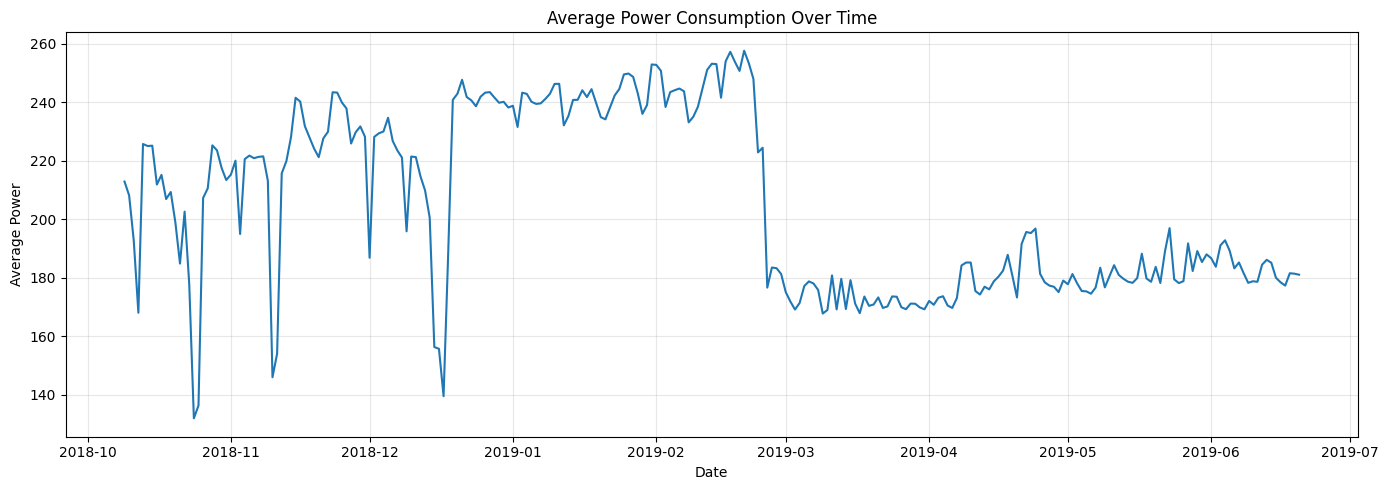

In [19]:
df['Time'] = pd.to_datetime(df['Time'])
daily_power = (df.set_index("Time")["Power"].resample("D").mean())

plt.figure(figsize=(14, 5))
plt.plot(daily_power.index, daily_power.values)
plt.title("Average Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Average Power")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Average Power by day of week**

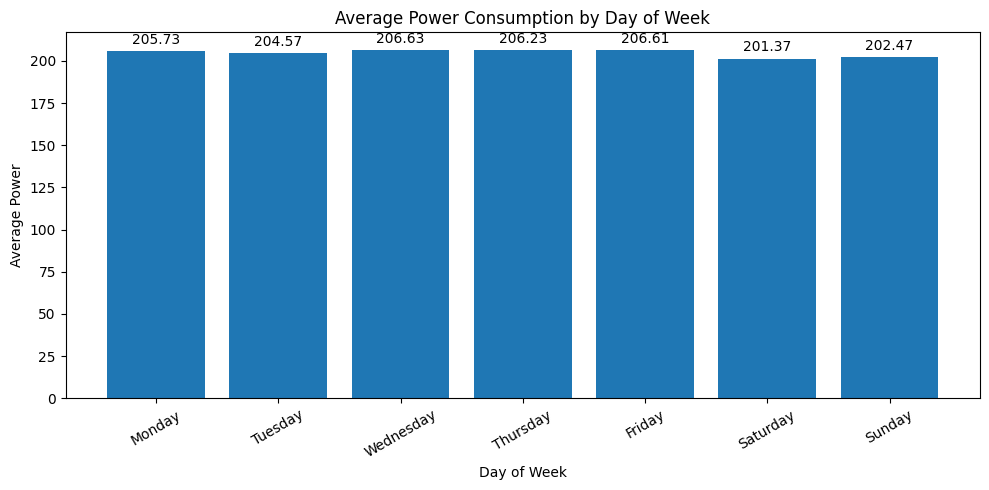

In [20]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day_of_Week"] = df["Time"].dt.day_name()
weekday_power = (df.groupby("Day_of_Week")["Power"].mean().reindex(day_order))

plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_power.index, weekday_power.values)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Average Power Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Power")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Univariate analysis**

**3. Numerical Feature Distributions**

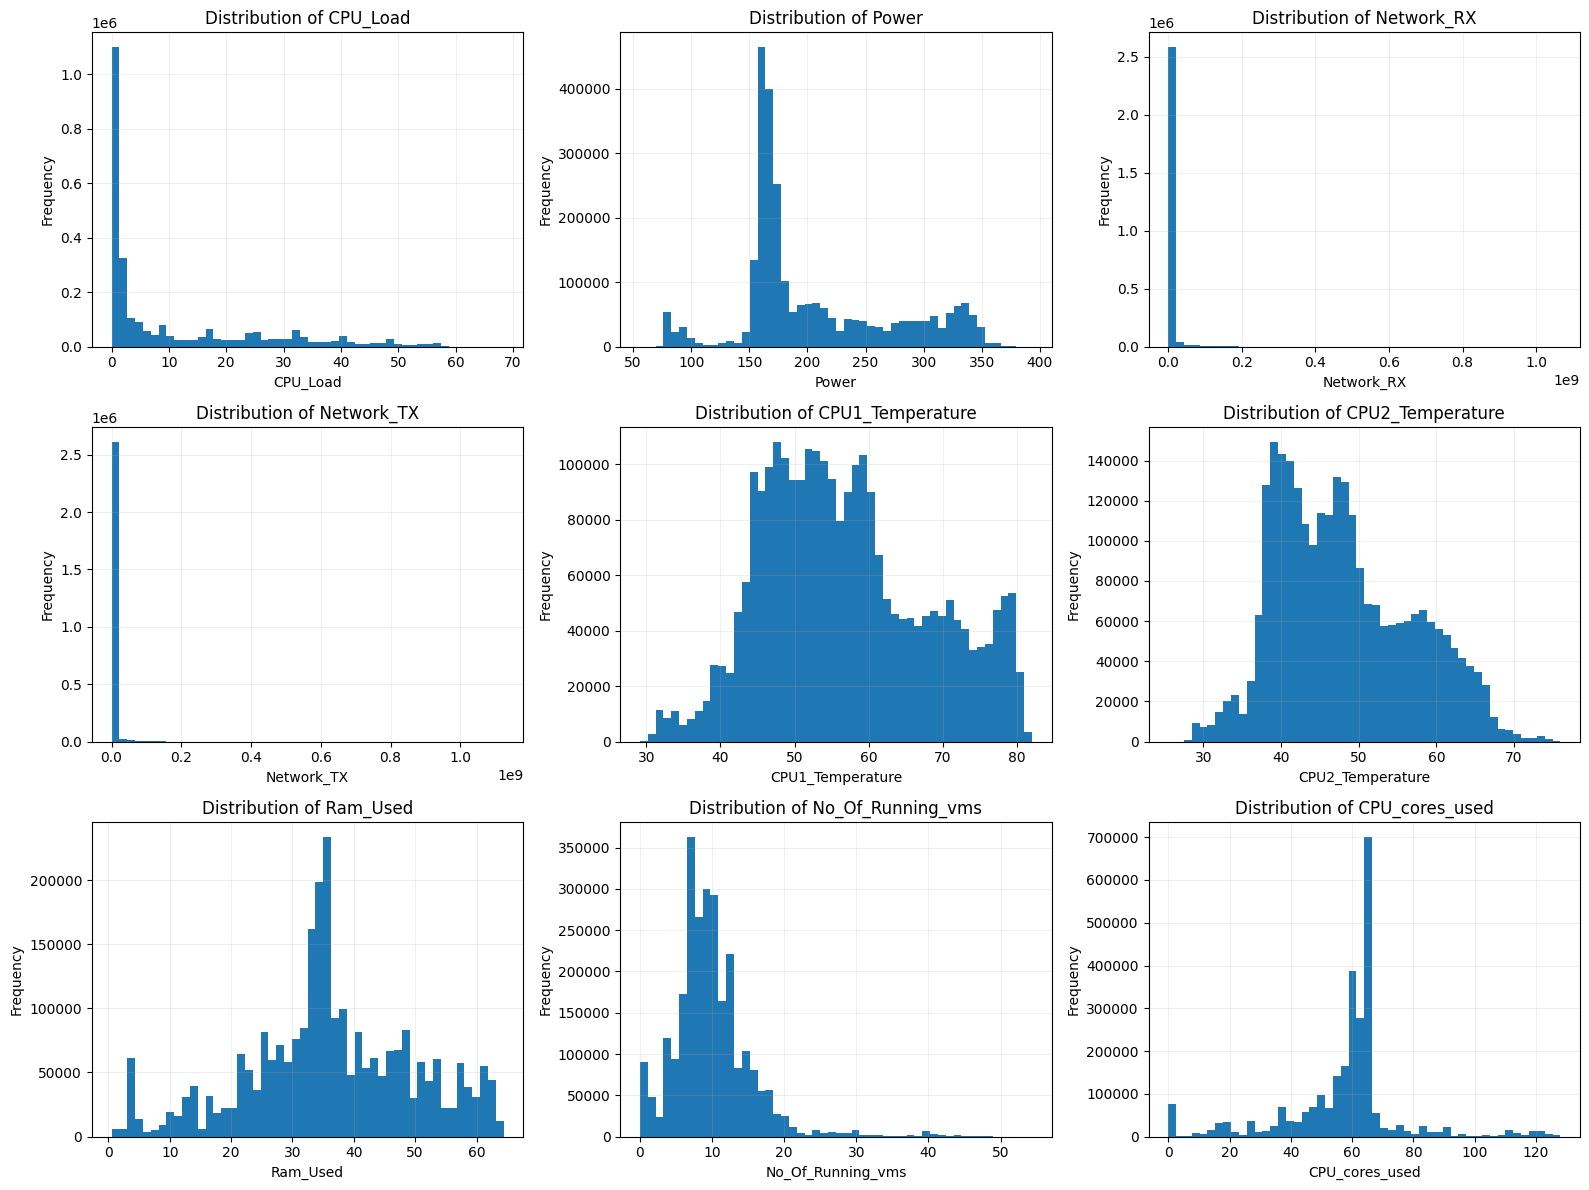

In [21]:
dist_cols = [
    "CPU_Load",
    "Power",
    "Network_RX",
    "Network_TX",
    "CPU1_Temperature",
    "CPU2_Temperature",
    "Ram_Used",
    "No_Of_Running_vms",
    "CPU_cores_used"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, dist_cols):
    ax.hist(df[col], bins=50)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**4. Outlier Inspection**

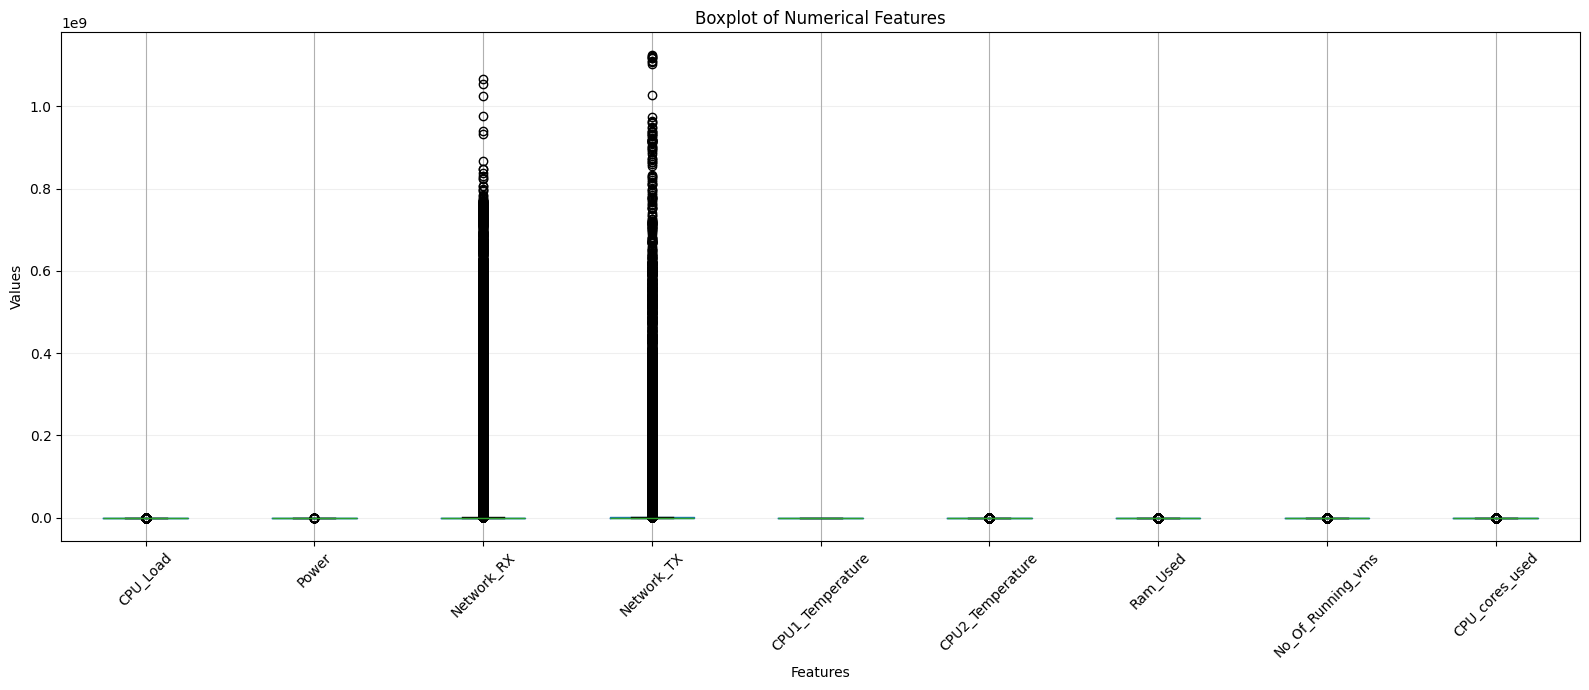

In [22]:
box_cols = [
    "CPU_Load",
    "Power",
    "Network_RX",
    "Network_TX",
    "CPU1_Temperature",
    "CPU2_Temperature",
    "Ram_Used",
    "No_Of_Running_vms",
    "CPU_cores_used"
]

plt.figure(figsize=(16, 7))
df[box_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Series analysis**

**5. Average Power by Server**

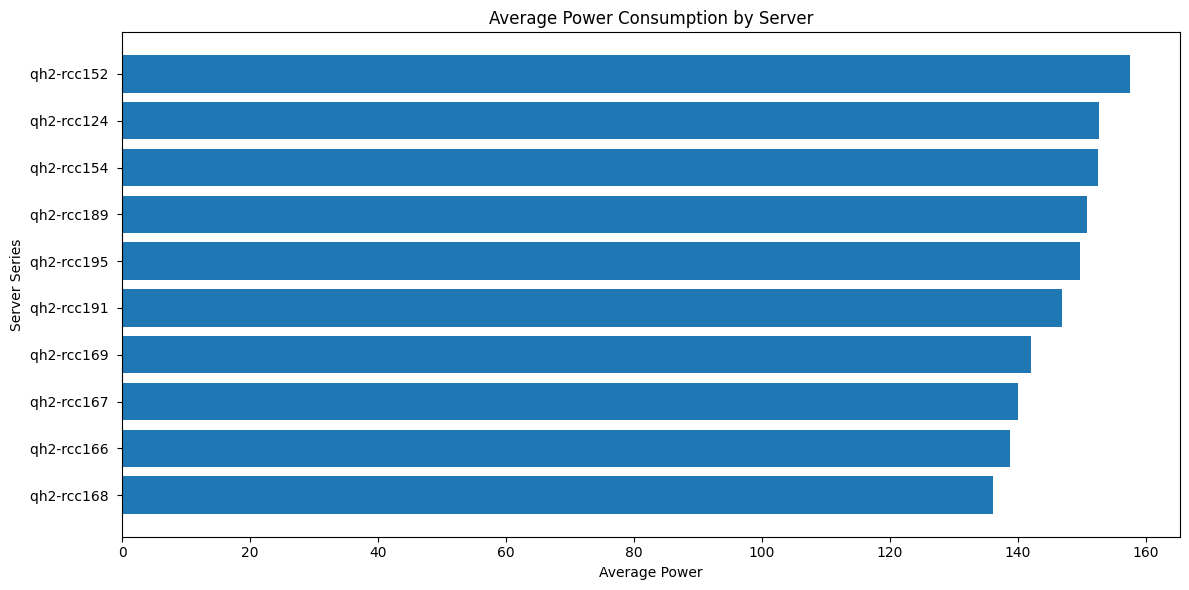

In [23]:
series_power = (df.groupby("Series")["Power"].mean().sort_values()).head(10)

plt.figure(figsize=(12, 6))
plt.barh(series_power.index, series_power.values)
plt.title("Average Power Consumption by Server")
plt.xlabel("Average Power")
plt.ylabel("Server Series")
plt.tight_layout()
plt.show()

**Relationship Analysis**

**6. Correlation Heatmap**

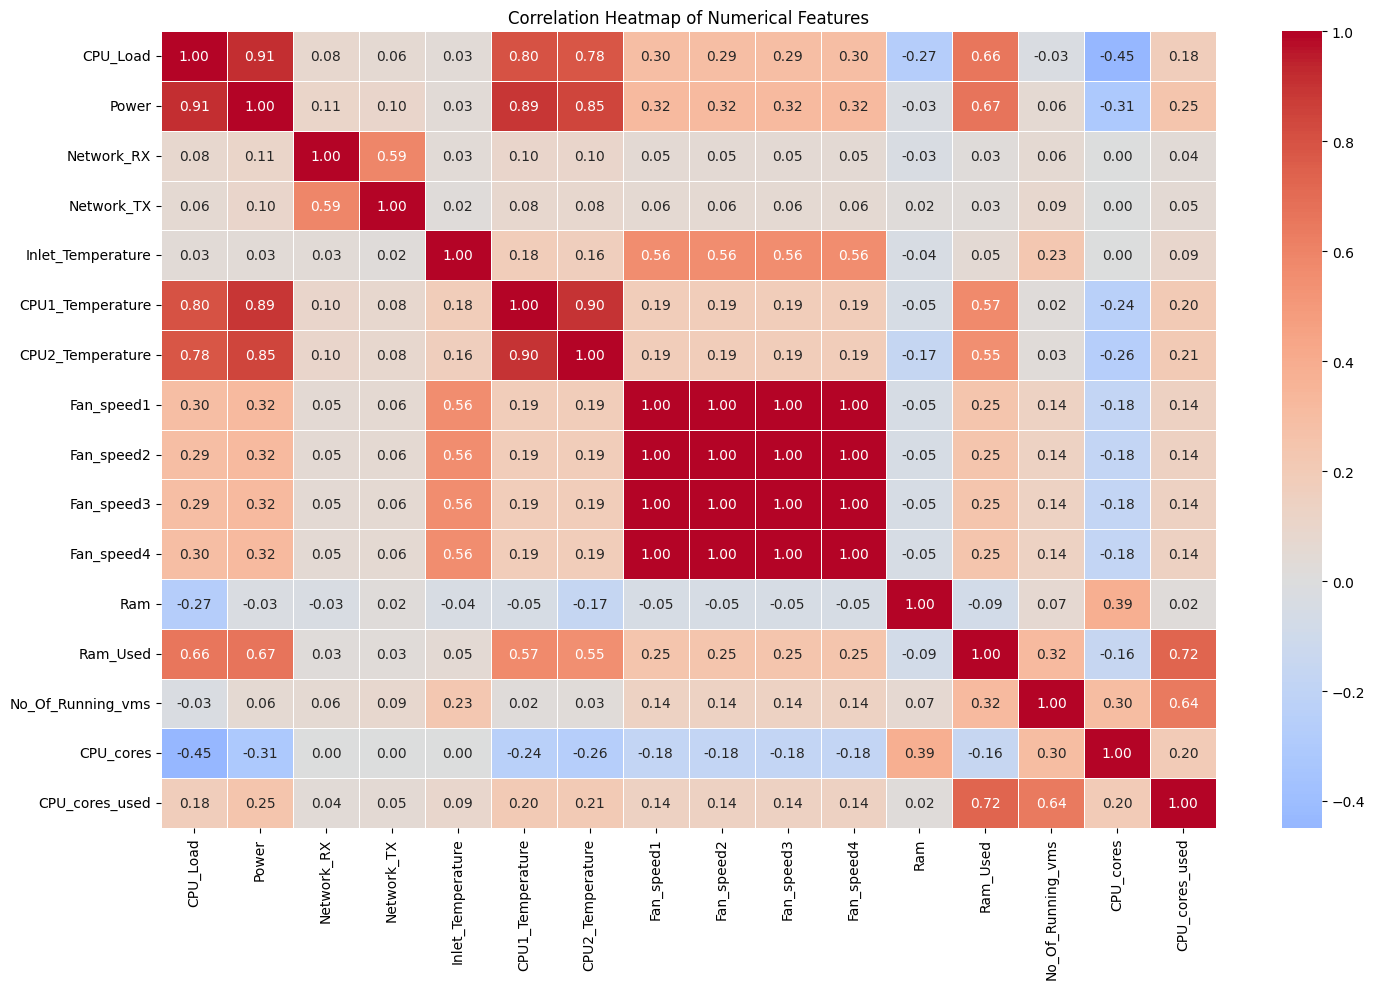

In [24]:
numeric_cols = df.select_dtypes(include="number").columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**7. Grouped System Relationships**

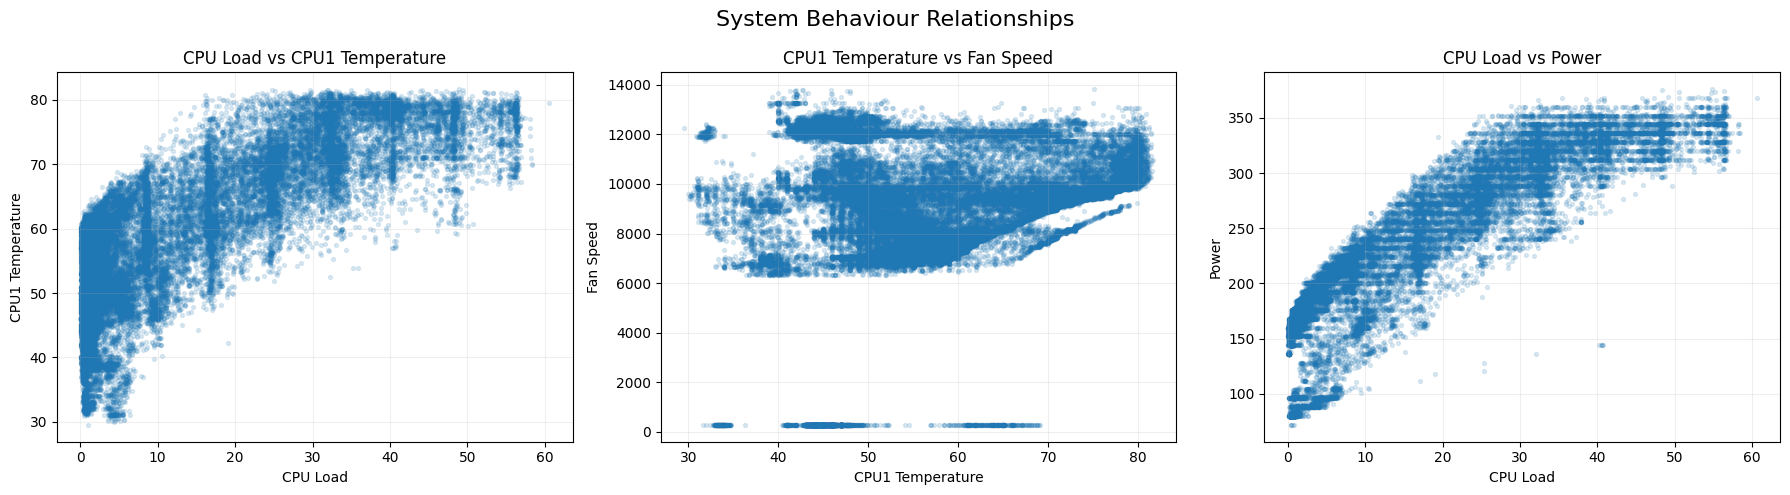

In [25]:
sample = df.sample(n=min(50000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. CPU Load vs CPU Temperature
axes[0].scatter(
    sample["CPU_Load"],
    sample["CPU1_Temperature"],
    alpha=0.15,
    s=8
)
axes[0].set_title("CPU Load vs CPU1 Temperature")
axes[0].set_xlabel("CPU Load")
axes[0].set_ylabel("CPU1 Temperature")
axes[0].grid(True, alpha=0.2)

# 2. CPU Temperature vs Fan Speed
axes[1].scatter(
    sample["CPU1_Temperature"],
    sample["Fan_speed1"],
    alpha=0.15,
    s=8
)
axes[1].set_title("CPU1 Temperature vs Fan Speed")
axes[1].set_xlabel("CPU1 Temperature")
axes[1].set_ylabel("Fan Speed")
axes[1].grid(True, alpha=0.2)

# 3. CPU Load vs Power
axes[2].scatter(
    sample["CPU_Load"],
    sample["Power"],
    alpha=0.15,
    s=8
)
axes[2].set_title("CPU Load vs Power")
axes[2].set_xlabel("CPU Load")
axes[2].set_ylabel("Power")
axes[2].grid(True, alpha=0.2)
plt.suptitle("System Behaviour Relationships", fontsize=16)
plt.tight_layout()
plt.show()

**Findings from above EDAV Plots**

- Power consumption shows variation over the observed time period, indicating that server power usage is not completely constant.

- The average power consumption varies across different days of the week, suggesting some differences in server activity depending on the day.

- The numerical features show different distributions and scales. In particular, Network_RX and Network_TX are highly right-skewed compared with most of the other variables.

- The boxplots indicate the presence of extreme values in several numerical variables. These values should be investigated further rather than removed automatically.

- The correlation heatmap shows strong relationships between several system metrics. CPU_Load and Power have a strong positive correlation, while CPU1_Temperature and CPU2_Temperature are also strongly correlated.

- The four fan-speed variables show extremely high correlation with each other, indicating that they provide very similar information.

- CPU Load and CPU Temperature show a positive relationship, suggesting that higher computational activity is generally associated with higher CPU temperature.

- CPU Temperature and Fan Speed also show a relationship, indicating changes in cooling activity as CPU temperature changes.

- Overall, the EDA shows that the dataset contains several related system-performance variables, along with some highly correlated and potentially redundant features.

#### Step 6: Feature Engineering and Extraction

**Workload Features**

In [26]:
df['CPU_Core_Utilization'] = (df['CPU_cores_used'] / df['CPU_cores']) * 100

df['RAM_Utilization'] = (df['Ram_Used'] / df['Ram']) * 100

df['Total_Network'] = (df['Network_RX'] + df['Network_TX'])

df['VM_Density'] = (df['No_Of_Running_vms'] / df['CPU_cores'])

# Display the newly created features
display(df[['CPU_Core_Utilization', 'RAM_Utilization', 'Total_Network', 'VM_Density']].head())

# Checking descriptive statistics of newly created workload features
display(df[['CPU_Core_Utilization', 'RAM_Utilization', 'Total_Network', 'VM_Density']].describe())


,CPU_Core_Utilization,RAM_Utilization,Total_Network,VM_Density
0,98.4375,58.4948,5.560813e+05,0.234375
1,98.4375,58.4948,2.469853e+05,0.234375
2,98.4375,58.4948,1.980528e+05,0.234375
3,98.4375,58.4948,5.846334e+05,0.234375
4,98.4375,58.4948,1.192400e+06,0.234375


,CPU_Core_Utilization,RAM_Utilization,Total_Network,VM_Density
count,2.664813e+06,2.664813e+06,2.664813e+06,2.664813e+06
mean,6.973319e+01,5.613712e+01,5.257249e+06,1.169917e-01
std,2.893652e+01,2.115018e+01,2.910455e+07,6.098847e-02
min,0.000000e+00,7.703118e-01,0.000000e+00,0.000000e+00
25%,4.609375e+01,4.417449e+01,1.135782e+05,7.812500e-02
50%,8.125000e+01,5.504086e+01,2.732042e+05,1.093750e-01
75%,9.687500e+01,7.116789e+01,1.278230e+06,1.484375e-01
max,1.578125e+02,9.989882e+01,1.685331e+09,4.246094e-01


**Thermal Features**

In [27]:
df['Avg_CPU_Temperature'] = (df['CPU1_Temperature'] + df['CPU2_Temperature']) / 2

df['Max_CPU_Temperature'] = df[['CPU1_Temperature', 'CPU2_Temperature']].max(axis=1)

df['CPU_Temperature_Diff'] = abs(df['CPU1_Temperature'] - df['CPU2_Temperature'])

df['Temperature_Rise'] = df['Avg_CPU_Temperature'] - df['Inlet_Temperature']

# Checking descriptive statistics of newly created Thermal features
display(df[['Avg_CPU_Temperature', 'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise']].describe())

,Avg_CPU_Temperature,Max_CPU_Temperature,CPU_Temperature_Diff,Temperature_Rise
count,2.664813e+06,2.664813e+06,2.664813e+06,2.664813e+06
mean,5.245709e+01,5.699978e+01,9.085377e+00,3.471840e+01
std,9.699371e+00,1.118132e+01,4.694933e+00,9.745008e+00
min,2.795000e+01,2.930000e+01,0.000000e+00,9.433333e+00
25%,4.465833e+01,4.843333e+01,5.850000e+00,2.730833e+01
50%,5.124167e+01,5.551667e+01,8.683333e+00,3.342500e+01
75%,5.945833e+01,6.473333e+01,1.173333e+01,4.135000e+01
max,7.703333e+01,8.201667e+01,3.820000e+01,6.100000e+01


In [28]:
df[['Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Avg_CPU_Temperature', 'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise']].head()

,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Avg_CPU_Temperature,Max_CPU_Temperature,CPU_Temperature_Diff,Temperature_Rise
0,16.966667,37.083333,36.716667,36.900000,37.083333,0.366667,19.933333
1,17.000000,37.783333,37.083333,37.433333,37.783333,0.700000,20.433333
2,17.000000,38.233333,37.466667,37.850000,38.233333,0.766667,20.850000
3,17.000000,38.183333,37.550000,37.866667,38.183333,0.633333,20.866667
4,16.950000,37.416667,36.866667,37.141667,37.416667,0.550000,20.191667


**Cooling Features**

In [29]:
df['Avg_Fan_Speed'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].mean(axis=1)

df['Max_Fan_Speed'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].max(axis=1)

df['Fan_Speed_Diff'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].max(axis=1) - df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].min(axis=1)

In [30]:
# Checking descriptive statistics of newly created Cooling features

df[['Avg_Fan_Speed', 'Max_Fan_Speed', 'Fan_Speed_Diff']].describe()

,Avg_Fan_Speed,Max_Fan_Speed,Fan_Speed_Diff
count,2.664813e+06,2.664813e+06,2.664813e+06
mean,8.808856e+03,8.840577e+03,6.623485e+01
std,2.681616e+03,2.693287e+03,4.110645e+01
min,2.800000e+02,2.800000e+02,0.000000e+00
25%,7.361958e+03,7.401333e+03,3.406667e+01
50%,9.100292e+03,9.129167e+03,6.066667e+01
75%,1.048338e+04,1.051633e+04,9.450000e+01
max,1.391658e+04,1.394167e+04,5.142667e+02


In [31]:
# Hence all values for 4 fans_speeds are same we are only considering avg_fan_speed

df.drop(columns=['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Max_Fan_Speed', 'Fan_Speed_Diff'], inplace=True)

**Energy Features**

In [32]:
df['Power_per_Core'] = df['Power'] / df['CPU_cores']

df[['Power_per_Core']].describe()

,Power_per_Core
count,2.664813e+06
mean,2.638166e+00
std,1.382043e+00
min,8.729167e-01
25%,1.365625e+00
50%,2.500000e+00
75%,3.670833e+00
max,6.143750e+00


#### Cooling and Water-Demand Modeling

The IT power consumption is used to estimate the heat generated by the server infrastructure. Based on this heat load, the required cooling-water flow is estimated for different allowable water temperature rises.

An additional evaporative-water requirement is estimated using the latent heat of vaporization of water. These values represent physics-based estimates rather than directly measured water consumption.

In [33]:
# Heat load from IT power consumption
df['Heat_Load_kW'] = df['Power'] / 1000

In [34]:
# Water properties and cooling-system assumptions
CP_WATER = 4.1816  # kJ/(kg·°C) at approximately 25°C

DELTA_T_3C = 3
DELTA_T_5C = 5
DELTA_T_10C = 10

# Cooling-water flow requirement in L/hour
df['Water_Flow_3C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_3C)) * 3600
df['Water_Flow_5C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_5C)) * 3600
df['Water_Flow_10C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_10C)) * 3600

**Evaporative Water Requirement**

In [35]:
# Latent heat of vaporization of water at approximately 25°C
H_FG_WATER = 2441.7  # kJ/kg

# Evaporative water requirement in L/hour
df['Evaporative_Water_Required_LPH'] = (
    df['Heat_Load_kW'] / H_FG_WATER
) * 3600

In [36]:
# Check the resulting measures

df[['Power','Heat_Load_kW', 'Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH', 'Evaporative_Water_Required_LPH']].describe()

,Power,Heat_Load_kW,Water_Flow_3C_LPH,Water_Flow_5C_LPH,Water_Flow_10C_LPH,Evaporative_Water_Required_LPH
count,2.664813e+06,2.664813e+06,2.664813e+06,2.664813e+06,2.664813e+06,2.664813e+06
mean,2.048223e+02,2.048223e-01,5.877815e+01,3.526689e+01,1.763344e+01,3.019864e-01
std,6.593234e+01,6.593234e-02,1.892070e+01,1.135242e+01,5.676211e+00,9.720949e-02
min,5.586667e+01,5.586667e-02,1.603214e+01,9.619284e+00,4.809642e+00,8.236884e-02
25%,1.608000e+02,1.608000e-01,4.614502e+01,2.768701e+01,1.384350e+01,2.370807e-01
50%,1.760000e+02,1.760000e-01,5.050698e+01,3.030419e+01,1.515209e+01,2.594913e-01
75%,2.473333e+02,2.473333e-01,7.097762e+01,4.258657e+01,2.129328e+01,3.646640e-01
max,3.932000e+02,3.932000e-01,1.128372e+02,6.770231e+01,3.385116e+01,5.797272e-01


In [37]:
df[['Power', 'Heat_Load_kW', 'Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH', 'Evaporative_Water_Required_LPH']].head()

,Power,Heat_Load_kW,Water_Flow_3C_LPH,Water_Flow_5C_LPH,Water_Flow_10C_LPH,Evaporative_Water_Required_LPH
0,90.533333,0.090533,25.980486,15.588292,7.794146,0.133481
1,88.933333,0.088933,25.521332,15.312799,7.656399,0.131122
2,88.800000,0.088800,25.483069,15.289841,7.644921,0.130925
3,89.866667,0.089867,25.789172,15.473503,7.736751,0.132498
4,89.600000,0.089600,25.712646,15.427588,7.713794,0.132105


**Check All columns after Feature Engineering**

In [38]:
df.columns.to_list()

['Series',
 'Time',
 'CPU_Load',
 'Power',
 'Network_RX',
 'Network_TX',
 'Inlet_Temperature',
 'CPU1_Temperature',
 'CPU2_Temperature',
 'Ram',
 'Ram_Used',
 'No_Of_Running_vms',
 'CPU_cores',
 'CPU_cores_used',
 'Day_of_Week',
 'CPU_Core_Utilization',
 'RAM_Utilization',
 'Total_Network',
 'VM_Density',
 'Avg_CPU_Temperature',
 'Max_CPU_Temperature',
 'CPU_Temperature_Diff',
 'Temperature_Rise',
 'Avg_Fan_Speed',
 'Power_per_Core',
 'Heat_Load_kW',
 'Water_Flow_3C_LPH',
 'Water_Flow_5C_LPH',
 'Water_Flow_10C_LPH',
 'Evaporative_Water_Required_LPH']

#### **Save the Engineered Dataset for ML ready**

In [39]:
df.to_csv("..\datasets\Tu-wien_ML-Ready.csv", index = False)

#### Step 7: Cooling and Water-Demand Modeling

**Heat Load Analysis**

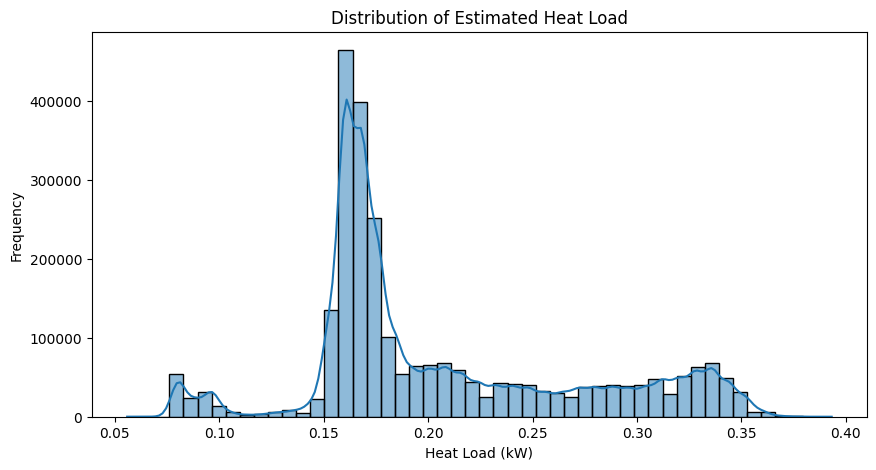

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Heat_Load_kW'], bins=50, kde=True)
plt.title('Distribution of Estimated Heat Load')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Frequency')
plt.show()

**Cooling Water Requirement**

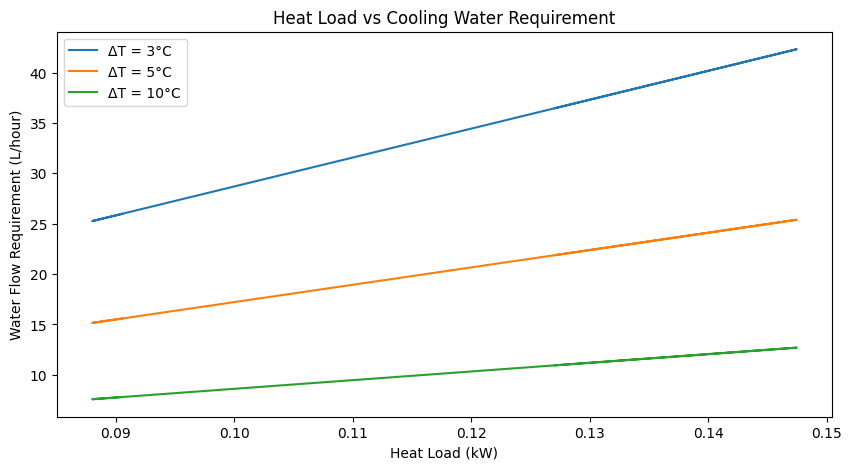

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_3C_LPH'].head(500), label='ΔT = 3°C')
plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_5C_LPH'].head(500), label='ΔT = 5°C')
plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_10C_LPH'].head(500), label='ΔT = 10°C')

plt.title('Heat Load vs Cooling Water Requirement')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Water Flow Requirement (L/hour)')
plt.legend()
plt.show()

**Evaporative Water Requirement**

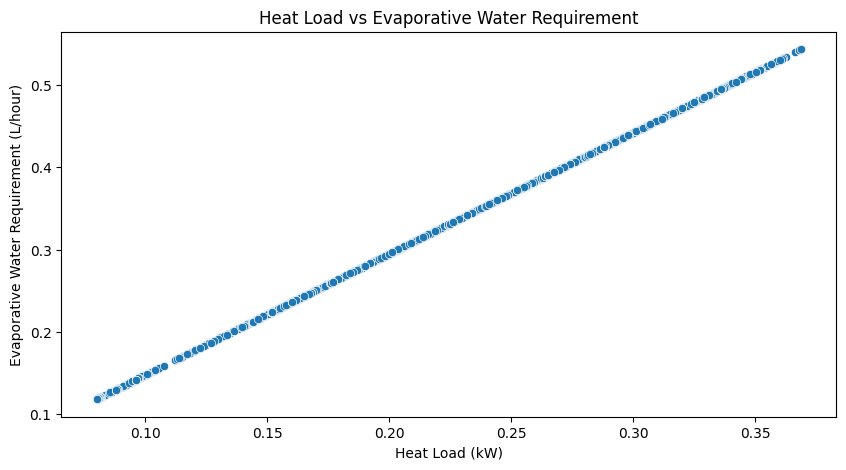

In [42]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='Heat_Load_kW',
    y='Evaporative_Water_Required_LPH'
)
plt.title('Heat Load vs Evaporative Water Requirement')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Evaporative Water Requirement (L/hour)')
plt.show()

**Scenario Comparison**

Water_Flow_3C_LPH     58.778149
Water_Flow_5C_LPH     35.266889
Water_Flow_10C_LPH    17.633445
dtype: float64


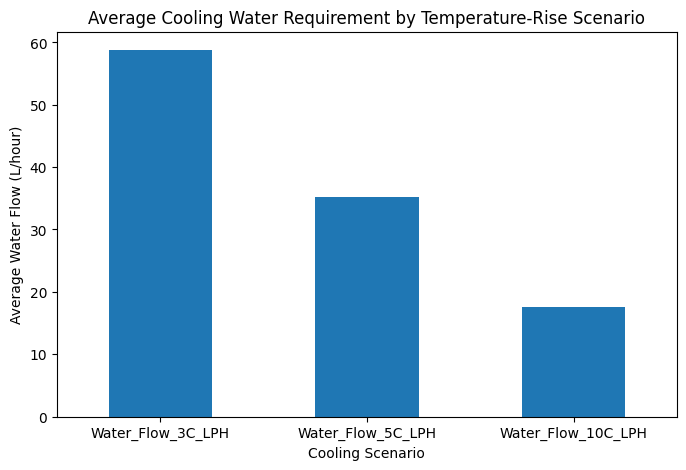

In [43]:
scenario_means = df[['Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH']].mean()
print(scenario_means)

plt.figure(figsize=(8, 5))
scenario_means.plot(kind='bar')
plt.title('Average Cooling Water Requirement by Temperature-Rise Scenario')
plt.xlabel('Cooling Scenario')
plt.ylabel('Average Water Flow (L/hour)')
plt.xticks(rotation=0)
plt.show()

**Power–Heat–Water Relationships**

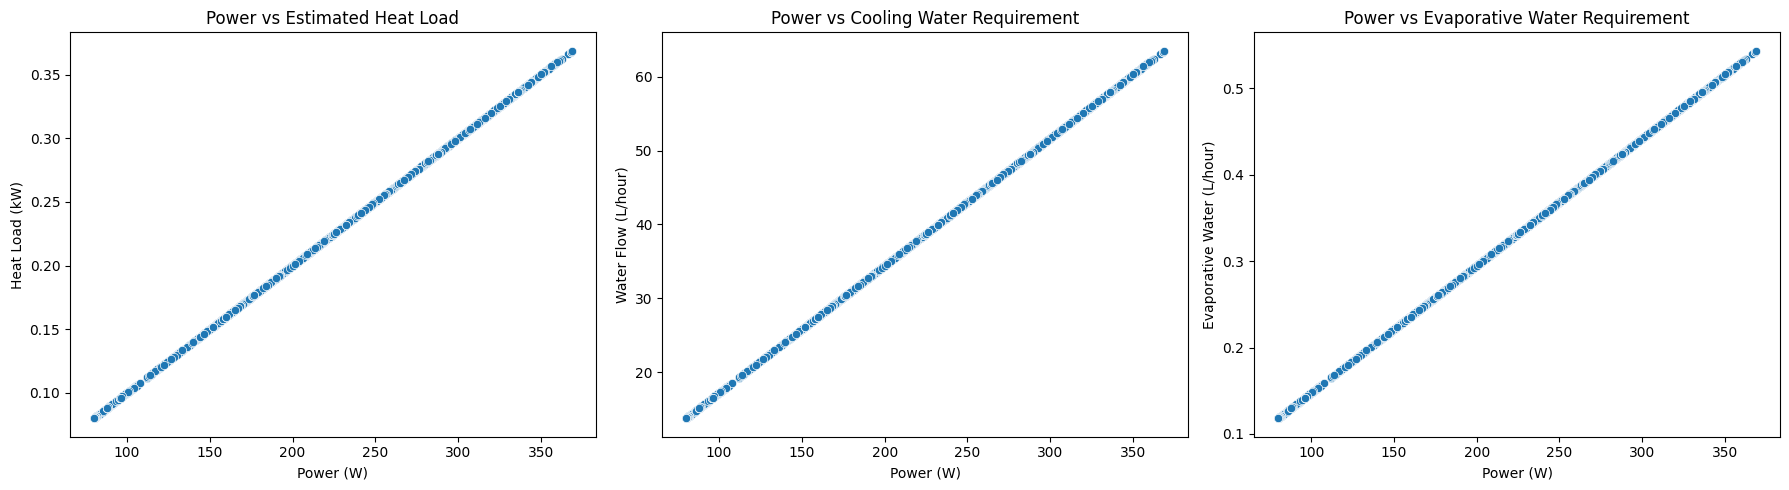

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_df = df.sample(min(10000, len(df)), random_state=42)

# Power vs Heat Load
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Heat_Load_kW',
    ax=axes[0]
)
axes[0].set_title('Power vs Estimated Heat Load')
axes[0].set_xlabel('Power (W)')
axes[0].set_ylabel('Heat Load (kW)')

# Power vs Cooling Water Requirement
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Water_Flow_5C_LPH',
    ax=axes[1]
)
axes[1].set_title('Power vs Cooling Water Requirement')
axes[1].set_xlabel('Power (W)')
axes[1].set_ylabel('Water Flow (L/hour)')

# Power vs Evaporative Water Requirement
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Evaporative_Water_Required_LPH',
    ax=axes[2]
)
axes[2].set_title('Power vs Evaporative Water Requirement')
axes[2].set_xlabel('Power (W)')
axes[2].set_ylabel('Evaporative Water (L/hour)')

plt.tight_layout()
plt.show()

The analysis shows a strong linear relationship between power consumption, estimated heat load, cooling-water flow requirement, and evaporative water requirement. This is expected because the cooling and water-demand measures are derived from the estimated heat load using thermodynamic relationships. These derived measures establish the physical basis for the subsequent predictive modeling stage.

#### Step 8: Predictive Modelling

### 8.1: Feature Selection

In [46]:
# Load data

data = pd.read_csv("..\datasets\Tu-wien_ML-Ready.csv")
data.columns

Index(['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX',
       'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Ram',
       'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used',
       'Day_of_Week', 'CPU_Core_Utilization', 'RAM_Utilization',
       'Total_Network', 'VM_Density', 'Avg_CPU_Temperature',
       'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise',
       'Avg_Fan_Speed', 'Power_per_Core', 'Heat_Load_kW', 'Water_Flow_3C_LPH',
       'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH',
       'Evaporative_Water_Required_LPH'],
      dtype='object')